Libraries imported successfully.
 Model loaded successfully from:
  ./Results/Trained_Models/RS42_consensus_n8_cv_safe_False_GradientBoosting_model.pkl

 Training data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n8_cv_safe_False_train_data.parquet (shape: (32, 9))
 Test data loaded successfully from:
  ./Results/Selected_Data/RS42_consensus_n8_cv_safe_False_test_data.parquet (shape: (9, 9))
 Predictions made for both training and test sets.
  - Training predictions shape: (32,)
  - Test predictions shape: (9,)
╔═════════════════╦═════════════╦═════════════╗
║   Metric        ║  Train Set  ║   Test Set  ║
╠═════════════════╬═════════════╬═════════════╣
║ R² (R-squared)  ║   0.7536    ║   0.5959    ║
║ RMSE            ║   14.75      ║   23.67      ║
╚═════════════════╩═════════════╩═════════════╝


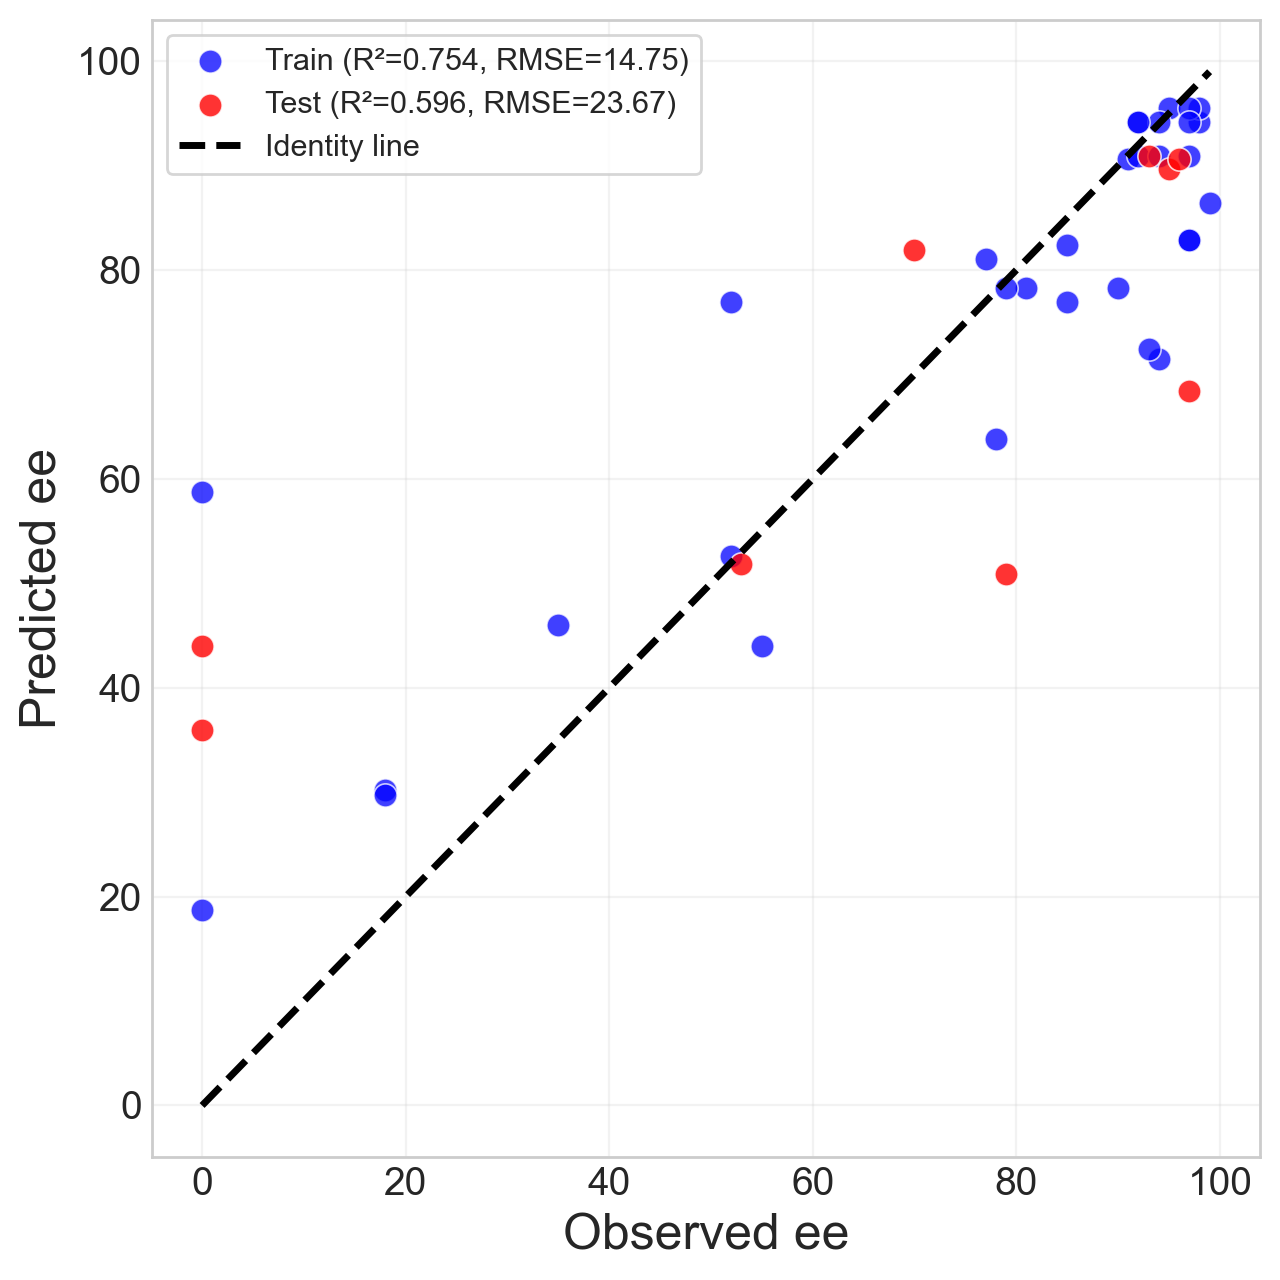

In [2]:
# # QSPR Model Verification and Visualization
# 
# This notebook loads a previously trained model and its corresponding training/test data to:
# 1.  Verify the model's performance by recalculating key metrics.
# 2.  Generate a publication-quality scatter plot of observed vs. predicted values.
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("Libraries imported successfully.")

# ===================================================================
# CONFIGURATION: Specify file paths
# ===================================================================
model_path = './Results/Trained_Models/RS42_consensus_n8_cv_safe_False_GradientBoosting_model.pkl'
train_data_path = './Results/Selected_Data/RS42_consensus_n8_cv_safe_False_train_data.parquet'
test_data_path = './Results/Selected_Data/RS42_consensus_n8_cv_safe_False_test_data.parquet'

# Load the model
model = joblib.load(model_path)
print(f" Model loaded successfully from:\n  {model_path}\n")

# Load the datasets
train_df = pd.read_parquet(train_data_path)
test_df = pd.read_parquet(test_data_path)
print(f" Training data loaded successfully from:\n  {train_data_path} (shape: {train_df.shape})")
print(f" Test data loaded successfully from:\n  {test_data_path} (shape: {test_df.shape})")
# ## Prepare Data and Make Predictions

# ===================================================================
# DATA PREPARATION AND PREDICTION
# ===================================================================
# Separate features (X) and target (y)
TARGET_COLUMN = 'ee'

X_train = train_df.drop(columns=[TARGET_COLUMN])
X_train = X_train[list(train_df.iloc[:, :-1].columns)]
y_train = train_df[TARGET_COLUMN]

X_test = test_df.drop(columns=[TARGET_COLUMN])
X_test = X_test[list(train_df.iloc[:, :-1].columns)]
y_test = test_df[TARGET_COLUMN]

# Make predictions
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

print(" Predictions made for both training and test sets.")
print(f"  - Training predictions shape: {y_pred_train.shape}")
print(f"  - Test predictions shape: {y_pred_test.shape}")

# ===================================================================
# PERFORMANCE VERIFICATION
# ===================================================================
# Calculate metrics for the training set
train_r2 = r2_score(y_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))

# Calculate metrics for the test set
test_r2 = r2_score(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

print("╔═════════════════╦═════════════╦═════════════╗")
print("║   Metric        ║  Train Set  ║   Test Set  ║")
print("╠═════════════════╬═════════════╬═════════════╣")
print(f"║ R² (R-squared)  ║   {train_r2:.4f}    ║   {test_r2:.4f}    ║")
print(f"║ RMSE            ║   {train_rmse:.2f}      ║   {test_rmse:.2f}      ║")
print("╚═════════════════╩═════════════╩═════════════╝")

# ===================================================================
# PLOT OBSERVED VS. PREDICTED (COMBINED) AND SAVE FIGURE
# ===================================================================
plt.style.use('seaborn-v0_8-whitegrid')

fig, ax = plt.subplots(figsize=(6.5, 6.5), dpi=200)

ax.scatter(
    y_train, y_pred_train,
    c='blue', alpha=0.75, s=70,
    edgecolors='white', linewidths=0.6,
    label=f'Train (R²={train_r2:.3f}, RMSE={train_rmse:.2f})'
)

ax.scatter(
    y_test, y_pred_test,
    c='red', alpha=0.80, s=70,
    edgecolors='white', linewidths=0.6,
    label=f'Test (R²={test_r2:.3f}, RMSE={test_rmse:.2f})'
)

all_y = np.concatenate([y_train, y_test])
all_pred = np.concatenate([y_pred_train, y_pred_test])
min_val = min(all_y.min(), all_pred.min())
max_val = max(all_y.max(), all_pred.max())

ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=2.5, label='Identity line')

ax.set_xlabel('Observed ee', fontsize=18)
ax.set_ylabel('Predicted ee', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=14)
ax.legend(loc='best', fontsize=11, frameon=True)
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('model_performance_combined_larger.svg', format='svg', bbox_inches='tight')
#plt.savefig('model_performance_combined_larger.png', format='png', dpi=300, bbox_inches='tight')
plt.show()